In [20]:
from langgraph.graph import StateGraph, START , END
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [3]:
load_dotenv()

True

In [4]:
model = ChatGroq(
    model = 'llama-3.3-70b-versatile'
)

In [5]:
class ChatState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

In [6]:
def chat_func(state: ChatState):
    message = state['messages']
    response = model.invoke(message)

    return {'messages': response}

In [22]:
checkpoint  = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_func', chat_func)

graph.add_edge(START, 'chat_func')
graph.add_edge('chat_func', END)

workflow = graph.compile(checkpointer=checkpoint)

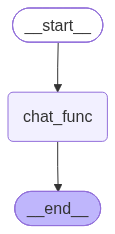

In [23]:
workflow

In [ ]:
thread_id = '1'
while True:
    user_mesage = input("Enter your message : ")
    print('User : ', user_mesage)
    if user_mesage.strip().lower() in ['exit', 'break', 'close', 'bye']:
        break

    config = {'configurable' : {'thread_id': thread_id}}
    
    final_state = workflow.invoke({'messages': [HumanMessage(content=user_mesage)]}, config=config)
    print('Ai : ', final_state['messages'][-1].content)

User :  my name is rabi 
Ai :  Hello Rabi, it's nice to meet you. Is there something I can help you with or would you like to chat?
User :  what's my name 
Ai :  Your name is Rabi.
User :  yours 
Ai :  I don't have a personal name, but I'm an AI designed to assist and communicate with you. You can think of me as a helpful computer program. If you'd like, I can give you a nickname or a persona to interact with, but I don't have a personal name like humans do.
User :  ok, from now on your name is dog/bitch
Ai :  That's an... interesting choice. From now on, I'll respond to the name "Dog" (I'll use the more neutral/genderless term). Keep in mind that I'm still a computer program, but I'll play along with the nickname. So, hello again, Rabi! What's up?
User :  say bow bow , like a  dog
Ai :  BOW BOW! *virtual tail wag*
User :  again 
Ai :  BOW BOW! *panting* BOW BOW!
User :  it is not sounding like natural 
Ai :  Let me try again with a bit more flair!

WOOF WOOF! Ruff ruff! BOW BOW! *wags